In [1]:
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import copy
import torch

In [2]:
@dataclass
class Pin:
    local_pos: np.ndarray
    net: str

@dataclass
class Component:
    id: str
    pos: np.ndarray
    theta: float = 0.0
    half_size: np.ndarray = field(default_factory=lambda: np.array([2.5, 2.5]))
    pins: list = field(default_factory=list)
    fixed: bool = False

def rot(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

def pin_world(component, pin):
    return component.pos + rot(component.theta) @ pin.local_pos

def rebuild_nets(components):
    nets = {}
    for cid, comp in components.items():
        for pi, pin in enumerate(comp.pins):
            nets.setdefault(pin.net, []).append((cid, pi))
    return nets

In [3]:
# Waterloo Hacker Fab tube furnace controller (phoenix_v2.kicad_sch)
# netlist extracted from the schematic; footprint geometry approximated from packages
board = np.array([[0, 0], [70, 0], [70, 50], [0, 50]], float)

rng = np.random.default_rng(7)
components = {}

def add(cid, hs, pin_specs, theta=0.0):
    components[cid] = Component(
        cid, rng.uniform([8, 8], [62, 42]), theta=theta,
        half_size=np.array(hs, float),
        pins=[Pin(np.array(lp, float), net) for lp, net in pin_specs],
    )

add("J1", (4.7, 3.7),
    [((-3.58, 3.70), "GND"),
     ((-0.27, 3.70), "GND"),
     ((-3.03, 3.70), "+5V"),
     ((-2.48, 3.70), "N2"),
     ((-1.93, 3.70), "UP_D+"),
     ((-1.38, 3.70), "UP_D-"),
     ((-0.83, 3.70), "+5V"),
     ((3.58, 3.70), "GND"),
     ((0.28, 3.70), "GND"),
     ((3.03, 3.70), "+5V"),
     ((2.48, 3.70), "N3"),
     ((1.92, 3.70), "UP_D+"),
     ((1.38, 3.70), "UP_D-"),
     ((0.83, 3.70), "+5V"),
     ((0.00, 0.00), "GND")])
add("J2", (5.0, 4.5),
    [((-2.50, -3.50), "N13"),
     ((2.50, -3.50), "N11")])
add("J3", (5.0, 4.5),
    [((-2.50, -3.50), "GND"),
     ((2.50, -3.50), "SSR_PWM")])
add("U1", (25.0, 12.0),
    [((-6.75, -12.00), "DISPLAY_RST"),
     ((6.75, -12.00), "GND"),
     ((-5.25, -12.00), "SCL"),
     ((-3.75, -12.00), "SDA"),
     ((-2.25, -12.00), "GND"),
     ((-0.75, -12.00), "+3.3V"),
     ((0.75, -12.00), "N12"),
     ((2.25, -12.00), "N7"),
     ((3.75, -12.00), "N6"),
     ((5.25, -12.00), "+3.3V")])
add("U2", (1.5, 1.4),
    [((-1.30, 0.95), "UP_D-"),
     ((-1.30, 0.00), "GND"),
     ((-1.30, -0.95), "UP_D+"),
     ((1.30, 0.95), "USB_D+"),
     ((1.30, 0.00), "+5V"),
     ((1.30, -0.95), "USB_D-")])
add("U3", (3.2, 2.5),
    [((-3.20, 1.95), "GND"),
     ((3.20, -0.65), "MAX_SCK"),
     ((3.20, 0.00), "MAX_SDO"),
     ((3.20, 0.65), "MAX_SDI"),
     ((3.20, 1.30), "MAX_FAULT"),
     ((3.20, 1.95), "GND"),
     ((-3.20, 1.30), "N11"),
     ((-3.20, 0.65), "N10"),
     ((-3.20, 0.00), "N9"),
     ((-3.20, -0.65), "+3.3V"),
     ((-3.20, -1.95), "MAX_DRDY"),
     ((3.20, -1.95), "+3.3V"),
     ((3.20, -1.30), "MAX_CS")])
add("U4", (1.5, 1.4),
    [((-1.30, 0.95), "+5V"),
     ((-1.30, 0.00), "GND"),
     ((-1.30, -0.95), "+5V"),
     ((1.30, -0.95), "GND"),
     ((1.30, 0.95), "+3.3V")])
add("U5", (9.0, 12.75),
    [((-9.00, 9.75), "+3.3V"),
     ((-9.00, -6.75), "ENC_A"),
     ((-8.25, -12.75), "DISPLAY_RST"),
     ((-6.75, -12.75), "LED_1"),
     ((-5.25, -12.75), "ENC_B"),
     ((-3.75, -12.75), "ENC_SW"),
     ((-9.00, 8.25), "GND"),
     ((2.25, -12.75), "N5"),
     ((9.00, -9.75), "MAX_SDO"),
     ((-9.00, 6.75), "LED_2"),
     ((9.00, -0.75), "MAX_SCK"),
     ((9.00, 0.75), "USB_D+"),
     ((9.00, 2.25), "USB_D-"),
     ((9.00, 3.75), "MAX_CS"),
     ((9.00, 5.25), "MAX_DRDY"),
     ((9.00, 6.75), "MAX_FAULT"),
     ((9.00, 8.25), "MAX_SDI"),
     ((-9.00, 5.25), "SCL"),
     ((9.00, 9.75), "+3.3V"),
     ((0.00, 0.00), "+3.3V"),
     ((-9.00, 3.75), "SDA"),
     ((-9.00, 0.75), "SSR_PWM"),
     ((-9.00, -2.25), "N4")])
add("C1", (1.6, 0.75),
    [((-1.00, 0.00), "N12"),
     ((1.00, 0.00), "+3.3V")])
add("C10", (1.6, 0.75),
    [((-1.00, 0.00), "GND"),
     ((1.00, 0.00), "+5V")])
add("C11", (1.6, 0.75),
    [((-1.00, 0.00), "GND"),
     ((1.00, 0.00), "+3.3V")])
add("C12", (1.9, 0.9),
    [((-1.30, 0.00), "GND"),
     ((1.30, 0.00), "+5V")])
add("C13", (1.9, 0.9),
    [((-1.30, 0.00), "GND"),
     ((1.30, 0.00), "+3.3V")])
add("C14", (1.9, 0.9),
    [((-1.30, 0.00), "GND"),
     ((1.30, 0.00), "+3.3V")])
add("C2", (1.6, 0.75),
    [((-1.00, 0.00), "N6"),
     ((1.00, 0.00), "N7")])
add("C3", (1.6, 0.75),
    [((-1.00, 0.00), "GND"),
     ((1.00, 0.00), "+3.3V")])
add("C4", (1.6, 0.75),
    [((-1.00, 0.00), "GND"),
     ((1.00, 0.00), "+3.3V")])
add("C5", (1.6, 0.75),
    [((-1.00, 0.00), "+3.3V"),
     ((1.00, 0.00), "GND")])
add("C6", (1.6, 0.75),
    [((-1.00, 0.00), "N9"),
     ((1.00, 0.00), "GND")])
add("C7", (1.6, 0.75),
    [((-1.00, 0.00), "N10"),
     ((1.00, 0.00), "N9")])
add("C8", (1.6, 0.75),
    [((-1.00, 0.00), "GND"),
     ((1.00, 0.00), "N10")])
add("C9", (1.6, 0.75),
    [((-1.00, 0.00), "N4"),
     ((1.00, 0.00), "GND")])
add("D1", (1.6, 0.75),
    [((-1.00, 0.00), "GND"),
     ((1.00, 0.00), "N1")])
add("D2", (1.6, 0.75),
    [((-1.00, 0.00), "GND"),
     ((1.00, 0.00), "N14")])
add("D3", (1.6, 0.75),
    [((-1.00, 0.00), "GND"),
     ((1.00, 0.00), "N15")])
add("R1", (1.6, 0.75),
    [((-1.00, 0.00), "N2"),
     ((1.00, 0.00), "GND")])
add("R10", (1.6, 0.75),
    [((-1.00, 0.00), "SDA"),
     ((1.00, 0.00), "+3.3V")])
add("R2", (1.6, 0.75),
    [((-1.00, 0.00), "N3"),
     ((1.00, 0.00), "GND")])
add("R3", (1.6, 0.75),
    [((-1.00, 0.00), "N13"),
     ((1.00, 0.00), "N9")])
add("R4", (1.6, 0.75),
    [((-1.00, 0.00), "N11"),
     ((1.00, 0.00), "N10")])
add("R5", (1.6, 0.75),
    [((-1.00, 0.00), "LED_1"),
     ((1.00, 0.00), "N1")])
add("R6", (1.6, 0.75),
    [((-1.00, 0.00), "LED_2"),
     ((1.00, 0.00), "N14")])
add("R7", (1.6, 0.75),
    [((1.00, 0.00), "N15")])
add("R8", (1.6, 0.75),
    [((-1.00, 0.00), "N4"),
     ((1.00, 0.00), "+3.3V")])
add("R9", (1.6, 0.75),
    [((-1.00, 0.00), "SCL"),
     ((1.00, 0.00), "+3.3V")])
add("SW1", (3.0, 3.0),
    [((-3.00, 0.00), "GND"),
     ((3.00, 0.00), "N4")])
add("SW2", (3.0, 3.0),
    [((-3.00, 0.00), "GND"),
     ((3.00, 0.00), "N5")])
add("SW3", (7.0, 6.25),
    [((-2.50, -6.00), "ENC_B"),
     ((0.00, -6.00), "ENC_A"),
     ((2.50, -6.00), "GND"),
     ((-2.50, 6.00), "ENC_SW"),
     ((2.50, 6.00), "GND")])

# connectors on the board edge, fixed
components["J1"].pos = np.array([35.0, 46.3]); components["J1"].fixed = True   # USB-C, top edge
components["J2"].pos = np.array([8.0, 4.5]);   components["J2"].fixed = True   # thermocouple, bottom-left
components["J3"].pos = np.array([60.0, 4.5]);  components["J3"].fixed = True   # SSR, bottom-right

rebuild_nets(components)

{'GND': [('J1', 0),
  ('J1', 1),
  ('J1', 7),
  ('J1', 8),
  ('J1', 14),
  ('J3', 0),
  ('U1', 1),
  ('U1', 4),
  ('U2', 1),
  ('U3', 0),
  ('U3', 5),
  ('U4', 1),
  ('U4', 3),
  ('U5', 6),
  ('C10', 0),
  ('C11', 0),
  ('C12', 0),
  ('C13', 0),
  ('C14', 0),
  ('C3', 0),
  ('C4', 0),
  ('C5', 1),
  ('C6', 1),
  ('C8', 0),
  ('C9', 1),
  ('D1', 0),
  ('D2', 0),
  ('D3', 0),
  ('R1', 1),
  ('R2', 1),
  ('SW1', 0),
  ('SW2', 0),
  ('SW3', 2),
  ('SW3', 4)],
 '+5V': [('J1', 2),
  ('J1', 6),
  ('J1', 9),
  ('J1', 13),
  ('U2', 4),
  ('U4', 0),
  ('U4', 2),
  ('C10', 1),
  ('C12', 1)],
 'N2': [('J1', 3), ('R1', 0)],
 'UP_D+': [('J1', 4), ('J1', 11), ('U2', 2)],
 'UP_D-': [('J1', 5), ('J1', 12), ('U2', 0)],
 'N3': [('J1', 10), ('R2', 0)],
 'N13': [('J2', 0), ('R3', 0)],
 'N11': [('J2', 1), ('U3', 6), ('R4', 0)],
 'SSR_PWM': [('J3', 1), ('U5', 21)],
 'DISPLAY_RST': [('U1', 0), ('U5', 2)],
 'SCL': [('U1', 2), ('U5', 17), ('R9', 0)],
 'SDA': [('U1', 3), ('U5', 20), ('R10', 0)],
 '+3.3V': [('U1'

In [4]:
ids = list(components)
hs = torch.tensor(np.array([components[c].half_size for c in ids]), dtype=torch.float32)
pos = torch.tensor(np.array([components[c].pos for c in ids]),
                   dtype=torch.float32, requires_grad=True)
theta = torch.tensor([components[c].theta for c in ids],
                     dtype=torch.float32, requires_grad=True)

fixed = torch.tensor([components[c].fixed for c in ids])
fixed_pos = pos.detach().clone()
fixed_theta = theta.detach().clone()

net_pins = []
for members in rebuild_nets(components).values():
    if len(members) < 2:
        continue
    net_pins.append([(ids.index(cid),
                      torch.tensor(components[cid].pins[pi].local_pos, dtype=torch.float32))
                     for cid, pi in members])

def pin_pos(i, off):
    c, s = torch.cos(theta[i]), torch.sin(theta[i])
    return pos[i] + torch.stack([c * off[0] - s * off[1],
                                 s * off[0] + c * off[1]])

def hs_eff():
    # AABB half-size of the rotated box -- differentiable in theta
    c, s = torch.cos(theta).abs(), torch.sin(theta).abs()
    return torch.stack([c * hs[:, 0] + s * hs[:, 1],
                        c * hs[:, 1] + s * hs[:, 0]], dim=1)


In [5]:
def hpwl(components):
    total = 0.0
    for members in rebuild_nets(components).values():
        if len(members) < 2:
            continue
        pts = np.array([pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members])
        total += np.ptp(pts[:, 0]) + np.ptp(pts[:, 1])
    return total
hpwl(components)

np.float64(1531.5945242399744)

In [6]:
# rect is on (lo, hi)
def project_position(c, lo, hi):
    c.pos = np.clip(c.pos, lo + c.half_size, hi - c.half_size)

In [7]:
def attractive(components, nets):
    F = {cid: np.zeros(2) for cid in components}
    for members in nets.values():
        if len(members) < 2:
            continue
        pts = [pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members]
        ctr = np.mean(pts, axis=0)
        for (cid, _), p in zip(members, pts):
            F[cid] += ctr - p
    return F
attractive(components, rebuild_nets(components))

{'J1': array([ -15.25114374, -226.8246477 ]),
 'J2': array([42.79650774, 24.89264771]),
 'J3': array([-45.99066831,  40.4329747 ]),
 'U1': array([179.99552643,   9.55391903]),
 'U2': array([-64.84183591,  55.2243078 ]),
 'U3': array([118.37439579,  67.43346219]),
 'U4': array([51.46306826, 34.85814551]),
 'U5': array([-55.63782489, -68.63891582]),
 'C1': array([-59.63411168, -17.63938568]),
 'C10': array([-18.19855234, -19.40147583]),
 'C11': array([19.36743735, 24.0795905 ]),
 'C12': array([-17.15747283,  44.85975767]),
 'C13': array([ 3.87673066e+01, -3.84309796e-02]),
 'C14': array([ -7.72947398, -27.39339978]),
 'C2': array([-30.6938913 ,  -1.55823376]),
 'C3': array([-11.04155427,  18.1429941 ]),
 'C4': array([41.347022  , 21.89066301]),
 'C5': array([-32.1186923 ,  21.33275157]),
 'C6': array([12.48249386, 26.83116166]),
 'C7': array([-27.31699894,  12.77300649]),
 'C8': array([ 24.30807297, -23.37427717]),
 'C9': array([ -7.22474462, -22.73913696]),
 'D1': array([-12.84404297,  

In [8]:
# TODO loop attract and repulse together?
def repulsive(components, k=30.0, slop=0.4):
    F = {cid: np.zeros(2) for cid in components}
    ids = list(components)
    for i in range(len(ids)):
        a = components[ids[i]]
        for j in range(i + 1, len(ids)):
            b = components[ids[j]]
            dx, dy = b.pos - a.pos
            ox = a.half_size[0] + b.half_size[0] + slop - abs(dx)
            oy = a.half_size[1] + b.half_size[1] + slop - abs(dy)
            if ox <= 0 or oy <= 0:
                continue
            if ox < oy:
                push = np.array([np.sign(dx or 1) * ox * k, 0.0])
            else:
                push = np.array([0.0, np.sign(dy or 1) * oy * k])
            F[ids[i]] -= push
            F[ids[j]] += push
    return F
repulsive(components)

{'J1': array([98.46014509,  0.        ]),
 'J2': array([0., 0.]),
 'J3': array([0., 0.]),
 'U1': array([-396.96743965, -476.72444112]),
 'U2': array([0., 0.]),
 'U3': array([-51.54435194,   0.        ]),
 'U4': array([  0.        , -30.32484525]),
 'U5': array([-161.02426246,  -47.2725849 ]),
 'C1': array([0., 0.]),
 'C10': array([3.06964831, 0.        ]),
 'C11': array([0., 0.]),
 'C12': array([0., 0.]),
 'C13': array([-26.57917141, -86.53360993]),
 'C14': array([72.27603237, 65.31120603]),
 'C2': array([128.02164724,   0.        ]),
 'C3': array([  16.37285151, -104.89792135]),
 'C4': array([0., 0.]),
 'C5': array([ 26.27614368, -16.50545427]),
 'C6': array([0., 0.]),
 'C7': array([0., 0.]),
 'C8': array([ 49.70674822, 334.21418969]),
 'C9': array([ 0.        , 85.14696076]),
 'D1': array([111.02636906,   0.        ]),
 'D2': array([  26.57917141, -108.81371105]),
 'D3': array([  0.        , 110.37318639]),
 'R1': array([ -97.87959609, -166.9947618 ]),
 'R10': array([0., 0.]),
 'R2':

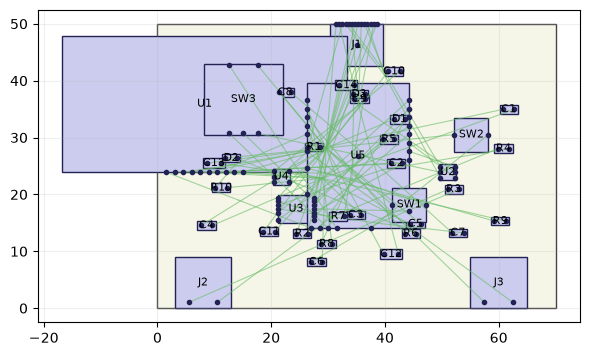

In [9]:
def draw(components, board, title=""):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.add_patch(patches.Polygon(board, facecolor="#f6f6e8", edgecolor="#444"))
    # draw ratsnest as star
    for net, members in rebuild_nets(components).items():
        if len(members) < 2:
            continue
        pts = [pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members]
        ctr = np.mean(pts, axis=0)  # centroid
        for p in pts: ax.plot([p[0], ctr[0]], [p[1], ctr[1]], "-", color="#6b6", alpha=0.6, lw=0.8)
    # draw components
    for cid, c in components.items():
        box = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]]) * c.half_size
        corners = (rot(c.theta) @ box.T).T + c.pos
        ax.add_patch(patches.Polygon(corners, facecolor="#cce", edgecolor="#225"))
        ax.text(*c.pos, cid, ha="center", va="center", fontsize=8)
        for p in c.pins:
            ax.plot(*pin_world(c, p), "o", color="#225", markersize=3)
    ax.autoscale_view()
    ax.grid(alpha=0.2)
    plt.show()

draw(components, board)

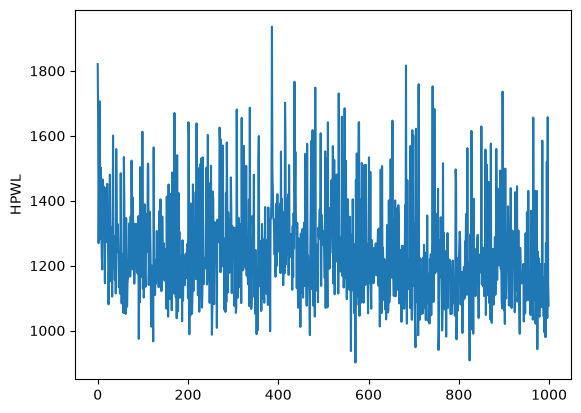

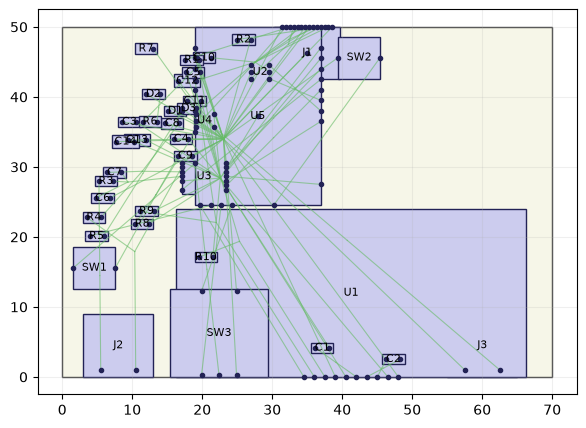

In [10]:
def step(components, dt=0.05):
    nets = rebuild_nets(components)
    Fa = attractive(components, nets)
    Fr = repulsive(components)
    for cid, c in components.items():
        if c.fixed:
            continue
        c.pos = c.pos + dt * (Fa[cid] + Fr[cid])
        project_position(c, board[0], board[2])

# randomize pos (keep fixed parts where they are)
rng = np.random.default_rng(0)
components_copy = copy.deepcopy(components)
for c in components_copy.values():
    if not c.fixed:
        c.pos = rng.uniform(board[0] + 4, board[2] - 4)

history = []
for _ in range(1000):
    step(components_copy)
    history.append(hpwl(components_copy))

plt.plot(history); plt.ylabel("HPWL"); plt.show()
draw(components_copy, board)


In [11]:
# helpers: copy tensor positions + rotations back into Component objects, then print + draw
def snapshot():
    snap = copy.deepcopy(components)
    p = pos.detach().numpy()
    t = theta.detach().numpy()
    for i, cid in enumerate(ids):
        snap[cid].pos = p[i].astype(float)
        snap[cid].theta = float(t[i])
    return snap

def show(title=""):
    snap = snapshot()
    print(f"{title}: HPWL = {hpwl(snap):.2f}")
    draw(snap, board, title)


before (WL only): HPWL = 1531.59


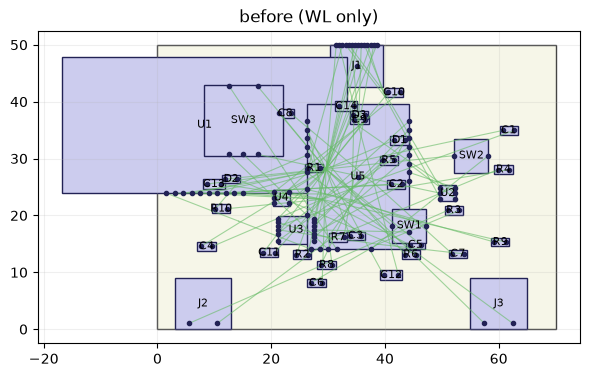

after (WL only): HPWL = 422.73


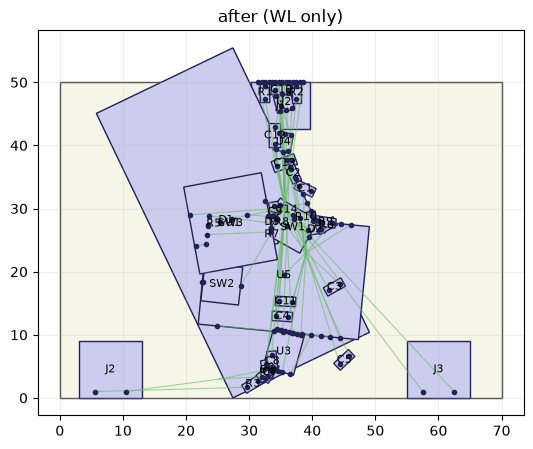

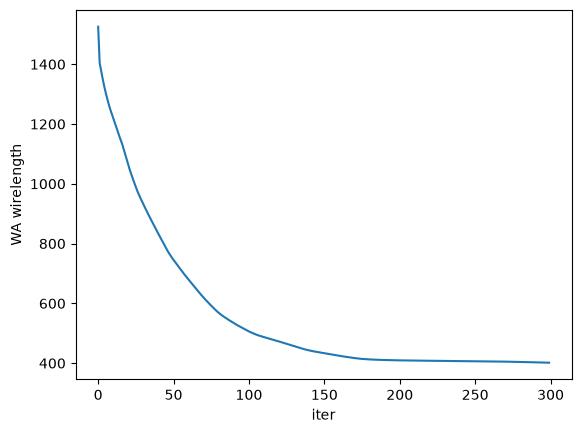

In [12]:
lo = torch.tensor(board[0], dtype=torch.float32)
hi = torch.tensor(board[2], dtype=torch.float32)

def wa_wirelength(gamma=1.0):
    total = 0.0
    for members in net_pins:
        pts = torch.stack([pin_pos(i, off) for i, off in members])
        for d in range(2):
            x = pts[:, d]
            total = total + (x * torch.softmax(x / gamma, 0)).sum() \
                          - (x * torch.softmax(-x / gamma, 0)).sum()
    return total

show("before (WL only)")

opt = torch.optim.Adam([{"params": [pos], "lr": 0.2},
                        {"params": [theta], "lr": 0.05}])
wl_hist = []
for it in range(300):
    opt.zero_grad()
    loss = wa_wirelength()
    loss.backward()
    opt.step()
    with torch.no_grad():
        pos.data[fixed] = fixed_pos[fixed]
        theta.data[fixed] = fixed_theta[fixed]
        h = hs_eff()
        pos.data = torch.max(torch.min(pos, hi - h), lo + h)
    wl_hist.append(loss.item())

show("after (WL only)")
plt.plot(wl_hist); plt.xlabel("iter"); plt.ylabel("WA wirelength"); plt.show()


In [13]:
M = 64  # bins per axis

bx = torch.linspace(lo[0], hi[0], M + 1)
by = torch.linspace(lo[1], hi[1], M + 1)
bin_area = (bx[1] - bx[0]) * (by[1] - by[0])

def density_map():
    h = hs_eff()   # rotation-aware footprint
    ox = (torch.minimum(pos[:, 0:1] + h[:, 0:1], bx[None, 1:])
        - torch.maximum(pos[:, 0:1] - h[:, 0:1], bx[None, :-1])).clamp(min=0)   # (n, M)
    oy = (torch.minimum(pos[:, 1:2] + h[:, 1:2], by[None, 1:])
        - torch.maximum(pos[:, 1:2] - h[:, 1:2], by[None, :-1])).clamp(min=0)   # (n, M)
    rho = torch.einsum("ni,nj->ij", ox, oy) / bin_area    # (M, M), area fraction per bin
    return rho


In [14]:
def electro_energy(rho):
    q = (rho - 1.0).clamp(min=0)              # only over-capacity density is charge
    q = q - q.mean()                          # neutralize for the periodic solve
    fx = torch.fft.fftfreq(M) * 2 * np.pi
    k2 = fx[:, None]**2 + fx[None, :]**2
    k2[0, 0] = 1.0                            # avoid div-by-zero at DC (q has no DC anyway)
    phi = torch.fft.ifft2(torch.fft.fft2(q) / k2).real
    return 0.5 * (q * phi).sum()

before (WL + density): HPWL = 1531.59


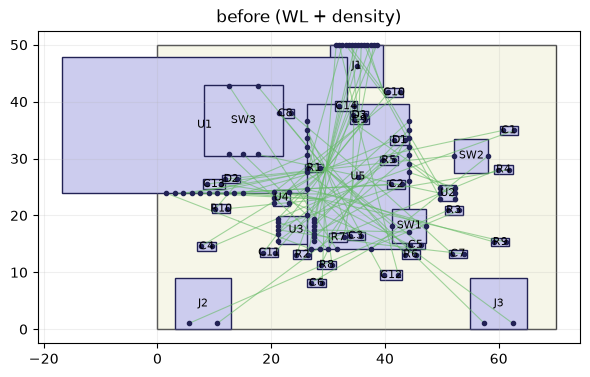

it    0  WL  1525.57  lam*density     6.79  snap   0.00  lam 0.0010  overflow 708.24
it  100  WL   604.65  lam*density    36.41  snap   0.00  lam 0.0198  overflow 287.04
it  200  WL   559.58  lam*density   356.49  snap   0.00  lam 0.3804  overflow 184.81
it  300  WL   609.29  lam*density  6520.59  snap   5.86  lam 7.3115  overflow 191.57
it  400  WL   834.97  lam*density 32772.71  snap  22.31  lam 140.5164  overflow 147.47
it  500  WL   836.10  lam*density 735681.69  snap  43.79  lam 2700.5336  overflow 154.99
after (WL + density + snap): HPWL = 901.37


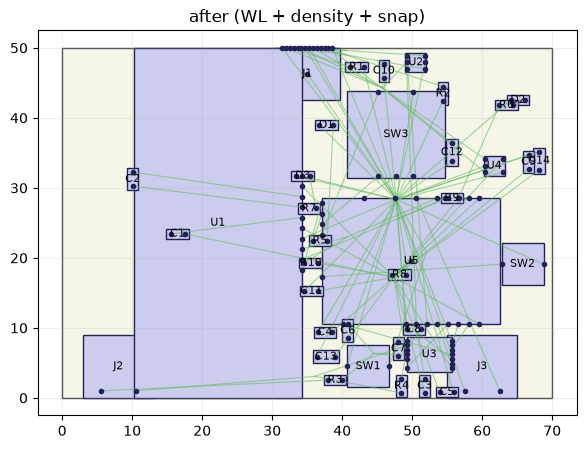

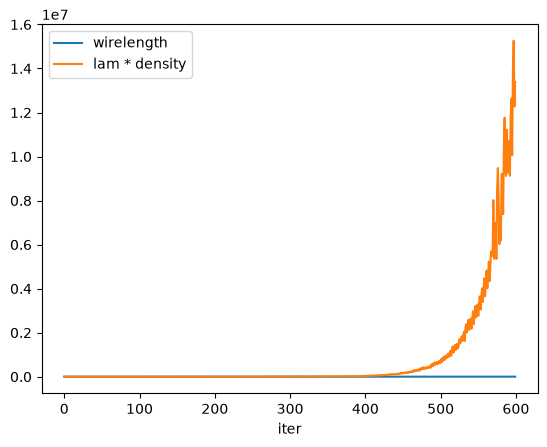

In [15]:
# reset to original placement (positions AND rotations)
pos.data = torch.tensor(np.array([components[c].pos for c in ids]), dtype=torch.float32)
theta.data = torch.tensor([components[c].theta for c in ids], dtype=torch.float32)
show("before (WL + density)")

opt = torch.optim.Adam([{"params": [pos], "lr": 0.2},
                        {"params": [theta], "lr": 0.05}])
lam, snap_w = 1e-3, 0.0
n_iters = 600
wl_hist, den_hist = [], []
for it in range(n_iters):
    opt.zero_grad()
    wl = wa_wirelength()
    den = lam * electro_energy(density_map())
    snap = snap_w * torch.sin(2 * theta).pow(2).sum()   # zero at every 90 degrees
    loss = wl + den + snap
    loss.backward()
    opt.step()
    with torch.no_grad():
        pos.data[fixed] = fixed_pos[fixed]
        theta.data[fixed] = fixed_theta[fixed]
        h = hs_eff()
        pos.data = torch.max(torch.min(pos, hi - h), lo + h)
    with torch.no_grad():   # overflow = total overlapped area; grow lam only while it exists
        overflow = ((density_map() - 1.0).clamp(min=0).sum() * bin_area).item()
    if overflow > 0.5:
        lam *= 1.03           # overlap remains: press harder
    elif overflow < 0.2:
        lam *= 0.97           # legal: relax so wirelength re-tightens
    if it > 0.4 * n_iters:                 # let parts rotate freely early, park them late
        snap_w = min(snap_w + 0.02, 5.0)
    wl_hist.append(wl.item()); den_hist.append(den.item())
    if it % 100 == 0:
        print(f"it {it:4d}  WL {wl.item():8.2f}  lam*density {den.item():8.2f}  "
              f"snap {snap.item():6.2f}  lam {lam:.4f}  overflow {overflow:6.2f}")

# legalize rotation: hard snap to nearest 90
with torch.no_grad():
    theta.data = torch.round(theta / (np.pi / 2)) * (np.pi / 2)
    theta.data[fixed] = fixed_theta[fixed]
    h = hs_eff()
    pos.data = torch.max(torch.min(pos, hi - h), lo + h)

show("after (WL + density + snap)")
plt.plot(wl_hist, label="wirelength")
plt.plot(den_hist, label="lam * density")
plt.xlabel("iter"); plt.legend(); plt.show()


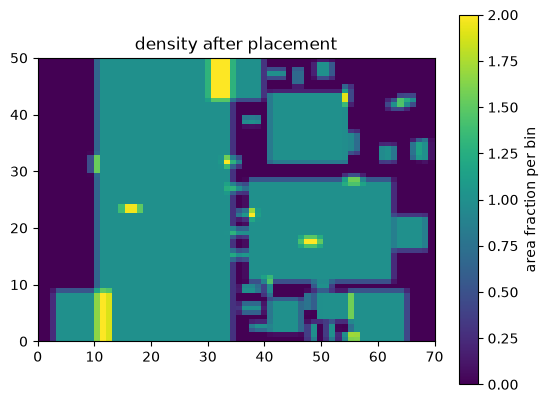

In [16]:
# final density map -- bright spots = remaining overlap
plt.imshow(density_map().detach().T, origin="lower",
           extent=[board[0][0], board[2][0], board[0][1], board[2][1]])
plt.colorbar(label="area fraction per bin")
plt.title("density after placement")
plt.show()
